In [ ]:
!pip install -q gradio torch torchvision torchaudio opencv-python-headless

from google.colab import drive
drive.mount('/content/drive')

import os
import cv2
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import gradio as gr


In [ ]:
# CHANGE this if your path is different
DATASET_PATH = "/content/drive/MyDrive/Sanskar_dataset_preprocessed"

IMG_SIZE = 128  # resize all images to 128x128

def ensure_binary(img_gray):
    """
    Take a grayscale image, convert to clean binary (0/255) using Otsu.
    """
    _, binary = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return binary

class OilSpillDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        label = self.labels[idx]

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"Could not read image: {path}")

        img = ensure_binary(img)               # make sure it is binary
        img = Image.fromarray(img)             # to PIL for torchvision

        if self.transform:
            img = self.transform(img)

        return img, label


In [ ]:
def collect_paths(root):
    """
    root = Sanskar_dataset_preprocessed
    Expected structure:
    root/
      NoSpill/Train/*.png
      NoSpill/Test/*.png
      OilSpill/Train/*.png
      OilSpill/Test/*.png
    """
    classes = ["NoSpill", "OilSpill"]
    train_paths, train_labels = [], []

    for label, cls in enumerate(classes):
        cls_train_dir = os.path.join(root, cls, "Train")
        if not os.path.isdir(cls_train_dir):
            print("Missing:", cls_train_dir)
            continue

        for name in os.listdir(cls_train_dir):
            if name.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")):
                train_paths.append(os.path.join(cls_train_dir, name))
                train_labels.append(label)

    print("Total train images:", len(train_paths))
    return train_paths, train_labels, classes

all_paths, all_labels, CLASS_NAMES = collect_paths(DATASET_PATH)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=0.2,
    stratify=all_labels,
    random_state=42,
)

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),          # -> 1 x H x W in [0,1]
    transforms.Normalize([0.5], [0.5])
])

train_dataset = OilSpillDataset(train_paths, train_labels, transform=transform)
val_dataset   = OilSpillDataset(val_paths,   val_labels,   transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)


In [ ]:
class OilSpillCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),          # 64x64
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),          # 32x32
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),          # 16x16
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = OilSpillCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


Epoch [1/30] Train Loss: 0.762 | Train Acc: 49.28% Val Loss: 0.693 | Val Acc: 49.59%
=> New best model saved with Val Acc: 49.59%
Epoch [2/30] Train Loss: 0.693 | Train Acc: 49.21% Val Loss: 0.693 | Val Acc: 49.59%
Epoch [3/30] Train Loss: 0.691 | Train Acc: 50.52% Val Loss: 0.688 | Val Acc: 59.50%
=> New best model saved with Val Acc: 59.50%
Epoch [4/30] Train Loss: 0.688 | Train Acc: 55.75% Val Loss: 0.688 | Val Acc: 56.20%
Epoch [5/30] Train Loss: 0.681 | Train Acc: 57.75% Val Loss: 0.686 | Val Acc: 50.69%
Epoch [6/30] Train Loss: 0.664 | Train Acc: 60.37% Val Loss: 0.656 | Val Acc: 61.16%
=> New best model saved with Val Acc: 61.16%
Epoch [7/30] Train Loss: 0.627 | Train Acc: 63.54% Val Loss: 0.681 | Val Acc: 58.68%
Epoch [8/30] Train Loss: 0.608 | Train Acc: 66.09% Val Loss: 0.671 | Val Acc: 56.75%
Epoch [9/30] Train Loss: 0.572 | Train Acc: 70.92% Val Loss: 0.704 | Val Acc: 55.92%
Epoch [10/30] Train Loss: 0.519 | Train Acc: 75.88% Val Loss: 0.722 | Val Acc: 57.58%
Epoch [11/30] 

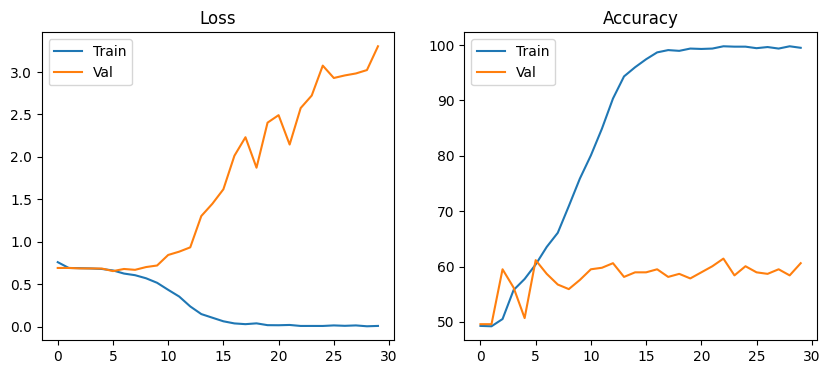

In [19]:
def train_model(model, train_loader, val_loader, epochs=30):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_val_acc = 0.0
    MODEL_PATH = "/content/drive/MyDrive/oilspill_binary_cnn_best.pth"

    for epoch in range(epochs):
        # ---- train ----
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total

        # ---- validation ----
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                v_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                v_total += labels.size(0)
                v_correct += (preds == labels).sum().item()

        val_loss = v_loss / len(val_loader)
        val_acc = 100 * v_correct / v_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        # print epoch stats
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.2f}% "
            f"Val Loss: {val_loss:.3f} | Val Acc: {val_acc:.2f}%"
        )

        # ---- save best model by val_acc ----
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "class_names": CLASS_NAMES
                },
                MODEL_PATH
            )
            print(f"=> New best model saved with Val Acc: {best_val_acc:.2f}%")

    # Plot
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Val")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label="Train")
    plt.plot(val_accs, label="Val")
    plt.title("Accuracy")
    plt.legend()
    plt.show()

    return train_losses, val_losses, train_accs, val_accs


# call training
train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, epochs=30
)


In [ ]:
# If you restart runtime later, reload model with this cell first:
# checkpoint = torch.load(MODEL_PATH, map_location=device)
# model = OilSpillCNN().to(device)
# model.load_state_dict(checkpoint["model_state_dict"])
# CLASS_NAMES = checkpoint["class_names"]

def gradio_predict(input_image):
    """
    input_image: RGB PIL image from Gradio.
    1. Convert to grayscale.
    2. Otsu binary.
    3. Resize and normalize.
    4. Run model.
    """
    if input_image is None:
        return None, "No image provided"

    # PIL -> np
    rgb = np.array(input_image)
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    binary = ensure_binary(gray)

    # For showing to user
    binary_vis = Image.fromarray(binary)

    # For model
    img = Image.fromarray(binary)
    x = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        out = model(x)
        probs = torch.softmax(out, dim=1)[0]
        pred = torch.argmax(probs).item()
        conf = probs[pred].item()

    label = CLASS_NAMES[pred]
    text = f"Prediction: {label}  |  Confidence: {conf:.2%}"
    return binary_vis, text

iface = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Image(type="pil", label="Upload SAR image"),
    outputs=[
        gr.Image(type="pil", label="Binary (Black & White)"),
        gr.Textbox(label="Result")
    ],
    title="SAR Oil Spill Detector",
    description="Uploads a SAR image, converts it to pure black & white, and classifies it as OilSpill or NoSpill."
)

iface.launch(debug=True)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://afcf8501279b925df4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
